# Image Generation for Handwritten Digits: Baseline

This notebook anchors the baseline training pipeline for image generation for mnist-like hand written digits with diffusion method **without any pretrained model**.
Fill in each `# TODO` placeholder before executing the training cell below.

## Setup and imports

In [9]:

import csv
from datetime import datetime
from pathlib import Path
from typing import Optional

import torch
from torch import nn
from torch.utils.data import DataLoader, Dataset
from torchvision import transforms, utils
from PIL import Image
from tqdm.auto import tqdm
import matplotlib.pyplot as plt

# Custom diffusion model structure
from diffusion_model import UNet, GaussianDiffusion


## Configuration

In [2]:

# Paths
DATA_ROOT = Path('../../dataset/mnist') 
OUTPUT_ROOT = Path('./logs')
RUN_ID = datetime.now().strftime('%Y%m%d-%H%M%S')  # unique folder per run
RUN_DIR = OUTPUT_ROOT / RUN_ID
RUN_DIR.mkdir(parents=True, exist_ok=True)
LOG_CSV = RUN_DIR / 'train_log.csv'

# Training hyperparameters
IMAGE_SIZE = 28
CHANNELS = 3
TIMESTEPS = 1000
BATCH_SIZE = 128
EPOCHS = 50
LEARNING_RATE = 2e-4
WEIGHT_DECAY = 1e-4
GRAD_CLIP = 1.0
EMA_DECAY = 0.999
NUM_WORKERS = 0
LOG_INTERVAL = 100  # steps
SAMPLE_EVERY_EPOCHS = 5
PROGRESS_FRAMES = 8  # for diffusion progress grid

# Reproducibility + device
GLOBAL_SEED = 314
torch.manual_seed(GLOBAL_SEED)
device = (
    torch.device('cuda') if torch.cuda.is_available()
    else torch.device('mps') if torch.backends.mps.is_available()
    else torch.device('cpu')
)
print(f'Using device: {device} Run directory: {RUN_DIR}')


Using device: cuda Run directory: logs/20251128-185612


## Data pipeline

In [3]:

class MNISTPngDataset(Dataset):
    """Dataset for flat directory of RGB MNIST PNGs."""

    def __init__(self, root: Path, transform: Optional[nn.Module] = None):
        self.root = Path(root)
        self.files = sorted(self.root.glob('*.png'))
        if len(self.files) == 0:
            raise ValueError(f'No PNG files found in {self.root}')
        self.transform = transform or transforms.Compose(
            [
                transforms.ToTensor(),  # [0,1]
                transforms.Normalize((0.5, 0.5, 0.5), (0.5, 0.5, 0.5)),  # [-1,1]
            ]
        )

    def __len__(self):
        return len(self.files)

    def __getitem__(self, idx):
        img_path = self.files[idx]
        with Image.open(img_path) as img:
            img = img.convert('RGB')
        return self.transform(img)


# DataLoader for training
dataset = MNISTPngDataset(DATA_ROOT)
train_loader = DataLoader(
    dataset,
    batch_size=BATCH_SIZE,
    shuffle=True,
    num_workers=NUM_WORKERS,
    pin_memory=torch.cuda.is_available(),
)
print(f'Loaded {len(dataset)} images')


Loaded 60000 images


## Model and diffusion objective

In [4]:

# Define UNet backbone and diffusion objective
unet = UNet(
    in_channels=CHANNELS,
    base_channels=64,
    channel_mults=(1, 2, 4),
    num_res_blocks=2,
    time_emb_dim=256,
    dropout=0.1,
    use_attention_at=(7,),
).to(device)

diffusion = GaussianDiffusion(
    model=unet,
    image_size=IMAGE_SIZE,
    channels=CHANNELS,
    timesteps=TIMESTEPS,
).to(device)

# Optimizer + mixed precision scaler
optimizer = torch.optim.AdamW(
    diffusion.parameters(), lr=LEARNING_RATE, weight_decay=WEIGHT_DECAY
)
scaler = torch.cuda.amp.GradScaler(enabled=torch.cuda.is_available())


/tmp/ipykernel_1358610/2443296647.py:23: FutureWarning: `torch.cuda.amp.GradScaler(args...)` is deprecated. Please use `torch.amp.GradScaler('cuda', args...)` instead.
  scaler = torch.cuda.amp.GradScaler(enabled=torch.cuda.is_available())


## Logging and metrics

In [5]:

def log_metrics(step: int, epoch: int, loss: float, path: Path = LOG_CSV):
    """Append training metrics to CSV log.

    Args:
        step: Global training step.
        epoch: Current epoch number.
        loss: Training loss value.
        path: CSV file to append to.
    """
    header = ['timestamp', 'step', 'epoch', 'loss']
    new_file = not path.exists()
    with path.open('a', newline='') as f:
        writer = csv.writer(f)
        if new_file:
            writer.writerow(header)
        writer.writerow([datetime.utcnow().isoformat(), step, epoch, loss])


@torch.no_grad()
def save_samples(step: int, num_samples: int = 16, use_ema: bool = False):
    """Save a grid of generated samples for quick visual inspection.

    Args:
        step: Global step used for filename.
        num_samples: Number of images to generate.
        use_ema: Whether to use EMA weights if available.
    """
    model_to_use = ema_model if use_ema and ema_model is not None else diffusion
    model_to_use.eval()
    samples = model_to_use.sample(num_samples, device)
    samples = (samples.clamp(-1, 1) + 1) * 0.5  # back to [0,1]
    grid = utils.make_grid(samples, nrow=int(num_samples ** 0.5))
    utils.save_image(grid, RUN_DIR / f'samples_step_{step:06d}.png')


@torch.no_grad()
def save_sampling_progress(step: int, num_samples: int = 8, frames: int = PROGRESS_FRAMES):
    """Save denoising trajectory grids for the report.

    Args:
        step: Global step used for filename.
        num_samples: Number of parallel samples to track.
        frames: Number of checkpoints across the diffusion timeline.
    """
    model_to_use = ema_model if ema_model is not None else diffusion
    model_to_use.eval()
    total_steps = model_to_use.timesteps
    checkpoints = torch.linspace(total_steps - 1, 0, frames, dtype=torch.long, device=device)
    x = torch.randn((num_samples, CHANNELS, IMAGE_SIZE, IMAGE_SIZE), device=device)
    saved = []
    for i in reversed(range(total_steps)):
        t_batch = torch.full((num_samples,), i, device=device, dtype=torch.long)
        x = model_to_use.p_sample(x, t_batch)
        if (checkpoints == i).any():
            clipped = (x.clamp(-1, 1) + 1) * 0.5
            saved.append(clipped.detach().cpu())
    if saved:
        grid = torch.cat(saved, dim=0)
        grid = utils.make_grid(grid, nrow=frames)
        utils.save_image(grid, RUN_DIR / f'sampling_progress_step_{step:06d}.png')


## Training utilities

In [6]:

def ema_update(ema_model: nn.Module, model: nn.Module, decay: float):
    """In-place EMA update of model parameters.

    Args:
        ema_model: Model holding EMA weights.
        model: Current training model.
        decay: EMA decay rate.
    """
    with torch.no_grad():
        ema_params = dict(ema_model.named_parameters())
        model_params = dict(model.named_parameters())
        for name, param in model_params.items():
            ema_params[name].data.mul_(decay).add_(param.data, alpha=1 - decay)


def train_one_epoch(epoch: int, global_step: int = 0, ema_model: nn.Module | None = None):
    """Run one training epoch over the dataset.

    Args:
        epoch: Epoch index (1-based).
        global_step: Running global step counter.
        ema_model: Optional EMA model to update.

    Returns:
        Tuple of (updated global_step, final loss of the epoch).
    """
    diffusion.train()
    pbar = tqdm(train_loader, desc=f'Epoch {epoch}')
    for step, batch in enumerate(pbar):
        batch = batch.to(device)
        optimizer.zero_grad(set_to_none=True)
        t = torch.randint(0, diffusion.timesteps, (batch.size(0),), device=device)
        with torch.cuda.amp.autocast(enabled=torch.cuda.is_available()):
            loss = diffusion.p_losses(batch, t)
        scaler.scale(loss).backward()
        if GRAD_CLIP is not None:
            scaler.unscale_(optimizer)
            torch.nn.utils.clip_grad_norm_(diffusion.parameters(), GRAD_CLIP)
        scaler.step(optimizer)
        scaler.update()

        if ema_model is not None:
            ema_update(ema_model, diffusion, EMA_DECAY)

        global_step += 1
        if global_step % LOG_INTERVAL == 0:
            log_metrics(global_step, epoch, loss.item())
        pbar.set_postfix({"loss": loss.item()})
    return global_step, loss.item()


## Training loop

In [7]:
ema_model = GaussianDiffusion(
    model=UNet(
        in_channels=CHANNELS,
        base_channels=64,
        channel_mults=(1, 2, 4),
        num_res_blocks=2,
        time_emb_dim=256,
        dropout=0.1,
        use_attention_at=(7,),
    ).to(device),
    image_size=IMAGE_SIZE,
    channels=CHANNELS,
    timesteps=TIMESTEPS,
).to(device)
ema_model.load_state_dict(diffusion.state_dict())

# Show the model architecture once before training
print('Diffusion model structure:')
print(diffusion)


global_step = 0
for epoch in range(1, EPOCHS + 1):
    global_step, loss = train_one_epoch(epoch, global_step, ema_model=ema_model)
    if epoch % SAMPLE_EVERY_EPOCHS == 0:
        save_samples(global_step, num_samples=25, use_ema=True)
        save_sampling_progress(global_step, num_samples=8, frames=PROGRESS_FRAMES)
    torch.save(
        {
            'diffusion': diffusion.state_dict(),
            'ema': ema_model.state_dict() if ema_model is not None else None,
            'optimizer': optimizer.state_dict(),
            'scaler': scaler.state_dict(),
            'epoch': epoch,
            'global_step': global_step,
            'run_id': RUN_ID,
        },
        RUN_DIR / f'checkpoint_epoch_{epoch:03d}.pt',
    )


Diffusion model structure:
GaussianDiffusion(
  (model): UNet(
    (time_embedding): Sequential(
      (0): SinusoidalPosEmb()
      (1): Linear(in_features=256, out_features=1024, bias=True)
      (2): SiLU()
      (3): Linear(in_features=1024, out_features=256, bias=True)
    )
    (init_conv): Conv2d(3, 64, kernel_size=(3, 3), stride=(1, 1), padding=(1, 1))
    (down): ModuleList(
      (0-1): 2 x ResidualBlock(
        (time_mlp): Sequential(
          (0): SiLU()
          (1): Linear(in_features=256, out_features=64, bias=True)
        )
        (block1): Sequential(
          (0): GroupNorm(8, 64, eps=1e-05, affine=True)
          (1): SiLU()
          (2): Conv2d(64, 64, kernel_size=(3, 3), stride=(1, 1), padding=(1, 1))
        )
        (block2): Sequential(
          (0): GroupNorm(8, 64, eps=1e-05, affine=True)
          (1): SiLU()
          (2): Dropout(p=0.1, inplace=False)
          (3): Conv2d(64, 64, kernel_size=(3, 3), stride=(1, 1), padding=(1, 1))
        )
       

Epoch 1:   0%|          | 0/469 [00:00<?, ?it/s]

/tmp/ipykernel_1358610/641298680.py:33: FutureWarning: `torch.cuda.amp.autocast(args...)` is deprecated. Please use `torch.amp.autocast('cuda', args...)` instead.
  with torch.cuda.amp.autocast(enabled=torch.cuda.is_available()):


Epoch 2:   0%|          | 0/469 [00:00<?, ?it/s]

Epoch 3:   0%|          | 0/469 [00:00<?, ?it/s]

...

Epoch 46:   0%|          | 0/469 [00:00<?, ?it/s]

Epoch 47:   0%|          | 0/469 [00:00<?, ?it/s]

Epoch 48:   0%|          | 0/469 [00:00<?, ?it/s]

Epoch 49:   0%|          | 0/469 [00:00<?, ?it/s]

Epoch 50:   0%|          | 0/469 [00:00<?, ?it/s]

Saved loss curve to logs/20251128-185612/train_loss_curve.png


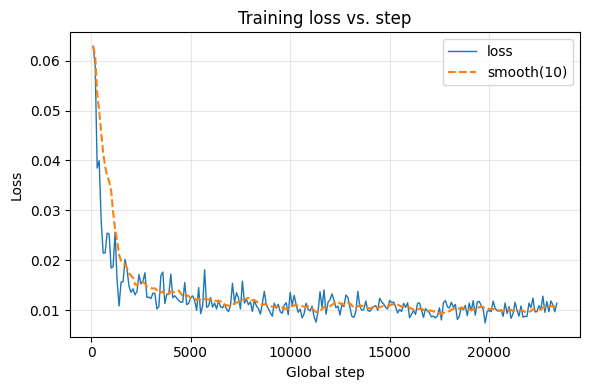

In [11]:

# Plot training loss over steps
def plot_training_loss(
    log_path: Path = LOG_CSV,
    smooth_window: int = 10,
    save: bool = True,
):
    """Plot training loss progression and optionally save the figure."""
    if not log_path.exists():
        print(f'No log file found at {log_path}. Run training first.')
        return None

    steps, losses = [], []
    with log_path.open() as f:
        reader = csv.DictReader(f)
        for row in reader:
            try:
                steps.append(int(row['step']))
                losses.append(float(row['loss']))
            except (KeyError, ValueError):
                continue

    if not steps:
        print('Log file has no valid entries yet.')
        return None

    fig, ax = plt.subplots(figsize=(6, 4))
    ax.plot(steps, losses, label='loss', color='tab:blue', linewidth=1)

    if smooth_window > 1 and len(losses) >= smooth_window:
        smooth = []
        cumulative = 0.0
        for i, value in enumerate(losses):
            cumulative += value
            if i >= smooth_window:
                cumulative -= losses[i - smooth_window]
            denom = min(i + 1, smooth_window)
            smooth.append(cumulative / denom)
        ax.plot(steps, smooth, label=f'smooth({smooth_window})', color='tab:orange', linestyle='--')

    ax.set_xlabel('Global step')
    ax.set_ylabel('Loss')
    ax.set_title('Training loss vs. step')
    ax.grid(alpha=0.3)
    ax.legend()
    fig.tight_layout()

    if save:
        out_path = log_path.parent / 'train_loss_curve.png'
        fig.savefig(out_path, dpi=200)
        print(f'Saved loss curve to {out_path}')

    plt.show()
    return fig

fig = plot_training_loss()
